# Final project - Ensemble Models

## Abstract


* Logistic regression is a common method used in binary classification and probability prediction. It allows categorizing data into discrete classes by studying the relationship from a given set of labelled data. 

* However, there are some datasets that internally are divisible into clusters and each of the clusters may have its own classification models. 

* Instead of using the traditional logistic regression, we are developing a new algorithm that splits the dataset into multiple subsets automatically, and then built an ensemble logistic model on subsets to provide a higher accuracy. 

* The algorithm is then implemented and tested on a sample dataset to show the performance improvement.

### The logistic regression

### The Model

The logistic function is of the form:


$$\large p(x)={\frac {1}{1+e^{-(\theta _{0}+\theta _{1}x)}}}=h_{\theta}(x)$$

### Fit - maximum likelihood estimation

Maximize the likelihood function, which is the probability that the given data set is produced by a particular logistic function:


$$\large L(\theta)=\prod _{k:y_{k}=1}p_{k}\,\prod _{k:y_{k}=0}(1-p_{k})$$


which is equivalent to maximize its log-likelihood:


$$\large \ell =\sum _{k:y_{k}=1}\ln(p_{k})+\sum _{k:y_{k}=0}\ln(1-p_{k})=\sum _{k=1}^{K}\left(\,y_{k}\ln(p_{k})+(1-y_{k})\ln(1-p_{k})\right)$$

### More details and implementation can be found in the attached PDF file within this project and the sample code below

https://github.com/SSaishruthi/LogisticRegression_Vectorized_Implementation/blob/master/Logistic_Regression.ipynb

# Your tasks

## Dataset

* Use the wine quality data set in the attached "allwine.csv"

## Task 1 (1 pts): Implement the simple logistic regression model

* Your goal is to predict "quality" by the 10 features - fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, density, pH, sulphates, and alcohol.
* Please follow the steps in the article and the sample jupyter notebook from In[1] to In[29] to implement your logistic regression and test the performance. You can reuse the sample code. 
* Only allow to use the modules as below. DO NOT use other modules or existing model APIs such as sklearn.linear_model.LogisticRegression

```
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
```

## Introduction of Ensemble Models

* Ensemble models is a machine learning approach to combine multiple other models in the prediction process. 
* Those models are referred to as base estimators. 

* It is a solution to overcome the following technical challenges of building a single estimator:
    * High variance: The model is very sensitive to the provided inputs to the learned features.
    * Low accuracy: One model or one algorithm to fit the entire training data might not be good enough to meet expectations.
    * Features noise and bias: The model relies heavily on one or a few features while making a prediction.
    
    
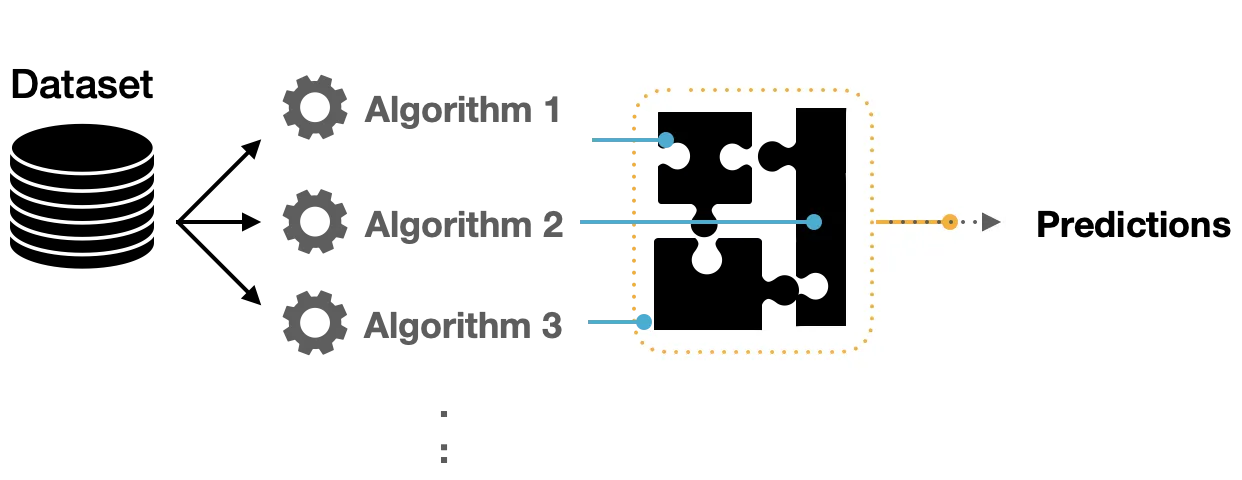

## The proposed technique in this research: the simplest dynamic ensemble logistic regression model

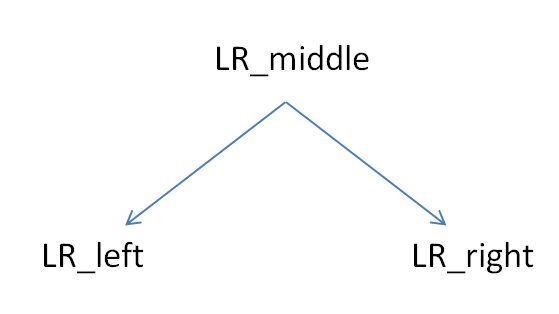


* This tree structure ensembles three logistic regression models.

* The logistic regression model on the top layer `LR_middle` takes the input data $x$, and then forwards the input $x$ to the second layer associated with the probability of classifying left as 

$$\large h_{\theta_{M}}(x)$$


* The probability of classifying right is

$$\large 1- h_{\theta_{M}}(x)$$

* The second layer has two logistic regression models: `LR_left` and `LR_right`.

* `LR_left`takes the input data $x$, and outputs the probability of classifying left as

$$\large h_{\theta_{L}}(x)$$

* Similarly, `LR_right`takes the input data $x$, and outputs the probability of classifying left as

$$\large h_{\theta_{R}}(x)$$

* Put them together, the data point $x_{i}$'s probability of classifying left is

$$\large P(y|x_{i},\theta_{M},\theta_{L},\theta_{R})=h_{\theta_{L}}(x)^y  (1-h_{\theta_{L}}(x))^{(1-y)}  h_{\theta_{M}}(x) + h_{\theta_{R}}(x)^y (1-h_{\theta_{R}}(x))^{(1-y)} (1-h_{\theta_{M}}(x))$$

* Let's double check the equation. If classifying left means $y=1$, then classifying right is $y=0$.

$$\large P(1|x_{i},\theta_{M},\theta_{L},\theta_{R})=h_{\theta_{L}}(x)  h_{\theta_{M}}(x) + h_{\theta_{R}}(x) (1-h_{\theta_{M}}(x))$$



$$\large P(0|x_{i},\theta_{M},\theta_{L},\theta_{R})=(1-h_{\theta_{L}}(x)) h_{\theta_{M}}(x) + (1-h_{\theta_{R}}(x))(1-h_{\theta_{M}}(x))$$
* Apparently, we can tell

$$\large P(1|x_{i},\theta_{M},\theta_{L},\theta_{R}) + P(0|x_{i},\theta_{M},\theta_{L},\theta_{R}) =1$$

### Similarly, we use maximum likelihood estimation

Maximize the likelihood function, which is the probability that the given data set is produced by a particular logistic function:


$$\large L(\theta_{M},\theta_{L},\theta_{R})=\prod _{i=1}^{n}P(y_i|x_{i},\theta_{M},\theta_{L},\theta_{R})$$

## Task 2 (4 pts): Implement the above dynamic ensemble logistic regression model

* Follow the same techniques of Task 1 to implement dynamic ensemble logistic regression model.
* Test the prediction performance. Your performance should be better than Task 1

## Task 3 (5 pts): Continue the research on deep dynamic ensemble model

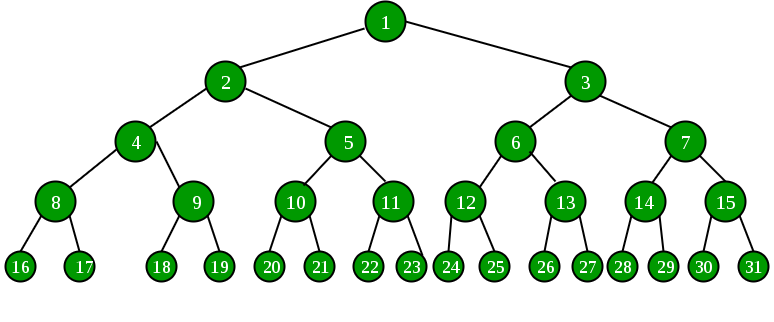

* Each of the nodes in the upper layers is a logistic regression model. 

* All of the nodes in the upper layers forward the input data associated with the probability to the two child nodes. The tree is essentially a diffusion process to split and spread the probability to the bottom layer. 

* The leaves at the bottom layer output the probability of classification or the prediction of regression.

* The final prediction will be the probability-weighted sum of all predictions of all leaves. 

### Your task is to implement the three-layer dynamic ensemble model which contains the nodes from 1 to 7 in the above graph.

* Your task is to derive the likelihood function as shown in Task 2 for the three-layer model, then implement the model and test the performance.

## Task 4 (Bonus, 0 pts) Generalize your model to support arbitrary number of layers

* This task is a bonus task. If you successfully finish this task, you will automatically exclude one lowest quiz score. 
* Quiz weight to final grade is 20%, which is computed by $Average(\text{4 Quizzes}) / 5$. If you get this bonus, your quiz weight becomes $Average(\text{3 highest Quizzes}) / 5$

# Submit:

Submit your jupyter notebook file and HTML file with all outputs. 

This is a group project. Each group may have up to 3 members. Solo is good too.

===============================

Some notes for the Task 2:

Please do NOT assume the "same weights" from 3 nodes because there is no place in the project mentioning it.
I have provided your cost function 

$$\large L(\theta_{M},\theta_{L},\theta_{R})=\prod _{i=1}^{n}P(y_i|x_{i},\theta_{M},\theta_{L},\theta_{R})$$

It is clear that you have three sets of thetas, theta_M, theta_L, theta_R. 
Each set of thetas have 10 parameters, so your cost function has total 30 independent parameters - all of the thetas. 
In other words, you have a function L with 30 parameters. Your goal is to to find the 30 values for your 30 thetas in order to maximize the above function.

# Grading

This is a group project. Each team may have up to 3 (three) members.

One person team will get two bonus points.

Two person team will get one bonus point for each member.



Late policy (-2.5 points per late day)

Submit in ipynb and HTML format on canvas. Each group only need to submit one copy on canvas. Please include all
members on the top of your jupyter notebook. Members added into team after submission will get zero points
